# Spatial Polarization

This notebook illustrates the `S` spatial polarization index implemented in `inequality.polarization`, based on the graph-intersection framework proposed in:

> Rey, S. J. (2026). Mind the gap and the map: measuring distributional and spatial income polarisation. *Spatial Economic Analysis*. https://doi.org/10.1080/17421772.2025.2606783

Polarization is distinct from inequality: following Esteban and Ray (1994), it combines *alienation* (how far apart groups are) with *group identification* (how homogeneous each group is). Zhang and Kanbur (2001) measure spatial polarization as a ratio of between-region to within-region inequality, but require an exogenously fixed partition of space into regions. Rey (2026) instead defines spatial polarization directly from two graphs built over the same set of `n` locations:

- an **attribute graph** `A`, connecting pairs of locations that fall in the same value class (e.g., both above or both below the median of some variable), and
- a **spatial graph** `G`, connecting pairs of locations that are geographic neighbours.

Intersecting `A` and `G` gives a graph `I` whose edges are pairs that are *both* attribute-similar and spatially adjacent. Comparing the number of connected components of `I`, `k_I`, against `k = max(k_A, k_G)` and `n` gives the index:

`S(A, G) = 1 - (k_I - k) / (n - k)`

`S` ranges from 0 (no overlap between spatial and attribute structure) to 1 (complete overlap: the connected pieces of the spatial graph line up exactly with the value classes). Splitting the attribute at the median (`k=2`) gives the *spatial bipolarization* index; using more than two classes generalizes to *spatial multipolarization*.

The `S` class below implements this index and adds a permutation-based inference procedure (randomly reshuffling the attribute values across locations) to obtain a pseudo p-value for the observed statistic - an extension beyond the purely descriptive index presented in the paper, which flags inference as a direction for future work.


In [1]:
from inequality.polarization import S

In [2]:
import libpysal
import numpy as np
import pandas as pd
from libpysal.graph import Graph
from libpysal.weights import lat2W

## A synthetic check: a regular 40x40 lattice

As a first, controlled example, we place `n = 1600` observations on a regular 40x40 lattice (contiguity via `lat2W`) and assign them the values `0, 1, ..., 1599` in row-major order. Because values increase steadily along each row before dropping back down at the start of the next, splitting at the median (`k=2`, the default) produces two attribute classes - low and high - that are each spatially contiguous within most rows. We should therefore expect a fairly high, though not perfect, spatial polarization value.

In [3]:
y = np.arange(1600)

In [4]:
df = pd.DataFrame({"y": y}, index=y)

In [5]:
g = Graph.from_W(lat2W(40, 40))

By default `S` runs `permutations=999` random reshuffles of the attribute values to build a null distribution, so `p_value` reports how (un)likely the observed spatial polarization would be if the values were randomly scattered across locations instead of following their actual spatial arrangement. `n_jobs=4` parallelizes the permutations across four worker processes.

In [6]:
res = S(df, g, "y", n_jobs=4)

  0%|          | 0/999 [00:00<?, ?it/s]

  1%|          | 8/999 [00:00<01:13, 13.43it/s]

  4%|▎         | 36/999 [00:00<00:15, 63.27it/s]

 26%|██▌       | 260/999 [00:00<00:01, 517.98it/s]

100%|██████████| 999/999 [00:00<00:00, 1108.24it/s]

In [7]:
res

S Spatial Polarization Summary
Variable:                                             y
n:                                                 1600
-------------------------------------------------------
S:                                               1.0000
p-value:                                         0.0010
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    2

Setting `permutations=0` skips the inference step entirely and returns just the observed statistic - useful when only the descriptive index is needed, or when many variables are being screened before running significance tests on the interesting ones.

In [8]:
res = S(df, g, "y", permutations=0)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [9]:
res

S Spatial Polarization Summary
Variable:                                             y
n:                                                 1600
-------------------------------------------------------
S:                                               1.0000
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    2

The `labels` attribute exposes the underlying classification for every location: `a_labels` is the attribute (value-class) membership, `g_labels` the spatial-graph component membership, and `i_labels` the component membership in the intersection graph `I` used to compute `S`.

In [10]:
res.labels

,i_labels,a_labels,g_labels
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
1595,1,1,0
1596,1,1,0
1597,1,1,0
1598,1,1,0


Since permutation inference is embarrassingly parallel, it's worth checking how much `n_jobs` helps in practice on this 1,600-observation lattice.

In [11]:
%%timeit
res = S(df, g, "y", n_jobs=4)

  0%|          | 0/999 [00:00<?, ?it/s]

 38%|███▊      | 376/999 [00:00<00:00, 3150.95it/s]

100%|██████████| 999/999 [00:00<00:00, 5727.70it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

 38%|███▊      | 376/999 [00:00<00:00, 3487.49it/s]

...

100%|██████████| 999/999 [00:00<00:00, 5733.33it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

 38%|███▊      | 376/999 [00:00<00:00, 3364.07it/s]

100%|██████████| 999/999 [00:00<00:00, 5935.92it/s]

382 ms ± 4.88 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


For reference, the full source of `S` - the sparse-graph component counting, quantile binning, and permutation loop - can be inspected directly.

In [12]:
S??

## Case study: Mexican state income, 1940-2000

The paper's illustrative application - reproduced here - examines per-capita GDP for Mexico's 32 states (31 states plus Ciudad de Mexico) at ten-year intervals from 1940 to 2000. The series extends Esquivel's (1999) 1940-1990 data with the 2000 figures from Rey and Sastre-Gutierrez (2010), and ships with `libpysal.examples` as the `"mexico"` dataset.

Across this 70-year span the distribution of state incomes shows persistent right skew and a pronounced north-south divide, with low-income states concentrated in the south. The question the spatial polarization index is built to answer is not just *how unequal* incomes are (that's the job of Theil's T or the Gini index), but *how spatially organized* that inequality is - do similarly poor, or similarly rich, states cluster together geographically?

In [13]:
libpysal.examples.explain("mexico")

mexico

Decennial per capita incomes of Mexican states 1940-2000
--------------------------------------------------------

* mexico.csv: attribute data. (n=32, k=13)
* mexico.gal: spatial weights in GAL format.
* mexicojoin.shp: Polygon shapefile. (n=32)

Data used in Rey, S.J. and M.L. Sastre Gutierrez. (2010) "Interregional inequality dynamics in Mexico." Spatial Economic Analysis, 5: 277-298.



In [14]:
mexico = libpysal.examples.load_example("mexico")

In [15]:
mexico.get_file_list()

['/home/runner/micromamba/envs/test/lib/python3.14/site-packages/libpysal/examples/mexico/mexico.gal',
 '/home/runner/micromamba/envs/test/lib/python3.14/site-packages/libpysal/examples/mexico/mexicojoin.shx',
 '/home/runner/micromamba/envs/test/lib/python3.14/site-packages/libpysal/examples/mexico/mexicojoin.shp',
 '/home/runner/micromamba/envs/test/lib/python3.14/site-packages/libpysal/examples/mexico/mexicojoin.dbf',
 '/home/runner/micromamba/envs/test/lib/python3.14/site-packages/libpysal/examples/mexico/mexico.csv',
 '/home/runner/micromamba/envs/test/lib/python3.14/site-packages/libpysal/examples/mexico/README.md',
 '/home/runner/micromamba/envs/test/lib/python3.14/site-packages/libpysal/examples/mexico/mexicojoin.prj']

In [16]:
import geopandas as gpd

In [17]:
gdf = gpd.read_file(libpysal.examples.get_path("mexicojoin.shp"))

<Axes: >

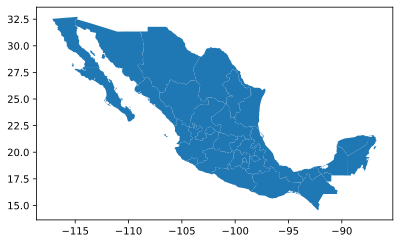

In [18]:
gdf.plot()

In [19]:
gdf.head()

,POLY_ID,AREA,CODE,NAME,PERIMETER,ACRES,HECTARES,PCGDP1940,PCGDP1950,PCGDP1960,...,GR9000,LPCGDP40,LPCGDP50,LPCGDP60,LPCGDP70,LPCGDP80,LPCGDP90,LPCGDP00,TEST,geometry
0,1,7.252751e+10,MX02,Baja California Norte,2040312.385,1.792187e+07,7252751.376,22361.0,20977.0,17865.0,...,0.05,4.35,4.32,4.25,4.40,4.47,4.43,4.48,1.0,"MULTIPOLYGON (((-113.13972 29.01778, -113.2405..."
1,2,7.225988e+10,MX03,Baja California Sur,2912880.772,1.785573e+07,7225987.769,9573.0,16013.0,16707.0,...,0.00,3.98,4.20,4.22,4.39,4.46,4.41,4.42,2.0,"MULTIPOLYGON (((-111.20612 25.80278, -111.2302..."
2,3,2.731957e+10,MX18,Nayarit,1034770.341,6.750785e+06,2731956.859,4836.0,7515.0,7621.0,...,-0.05,3.68,3.88,3.88,4.04,4.13,4.11,4.06,3.0,"MULTIPOLYGON (((-106.62108 21.56531, -106.6475..."
3,4,7.961008e+10,MX14,Jalisco,2324727.436,1.967200e+07,7961008.285,5309.0,8232.0,9953.0,...,0.03,3.73,3.92,4.00,4.21,4.32,4.30,4.33,4.0,"POLYGON ((-101.5249 21.85664, -101.5883 21.772..."
4,5,5.467030e+09,MX01,Aguascalientes,313895.530,1.350927e+06,546702.985,10384.0,6234.0,8714.0,...,0.13,4.02,3.79,3.94,4.21,4.32,4.32,4.44,5.0,"POLYGON ((-101.8462 22.01176, -101.9653 21.883..."


In [20]:
S?

The spatial graph `G` is built from queen contiguity among the 32 states (two states are neighbours if they share at least a boundary point). In the paper this graph is fully connected (`k_G = 1`), with a density of 13.5%, a median of 4 neighbours per state, ranging from 1 (Baja California Sur) to 9 (San Luis Potosi).

In [21]:
sg = Graph.build_contiguity(gdf)

In [22]:
sg.n_components

1

With `k=2` (the default), `S` splits `PCGDP1940` at its median to form the attribute graph - states above the median are mutually "neighbours" in `A`, as are states below it - and intersects it with the queen contiguity graph. This is the spatial bipolarization index. For 1940, the paper reports a value of 0.87: the low-income states form a single, large connected component running from the southern border up through the centre of the country, while the high-income states are split into five separate spatial clusters.

In [23]:
s1940 = S(gdf, sg, "PCGDP1940")

  0%|          | 0/999 [00:00<?, ?it/s]

 38%|███▊      | 376/999 [00:00<00:00, 3751.93it/s]

 75%|███████▌  | 752/999 [00:00<00:00, 3676.60it/s]

100%|██████████| 999/999 [00:00<00:00, 3722.73it/s]

In [24]:
s1940

S Spatial Polarization Summary
Variable:                                     PCGDP1940
n:                                                   32
-------------------------------------------------------
S:                                               0.8667
p-value:                                         0.1310
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    6

To trace how spatial bipolarization evolves, we repeat the calculation for each decade's income variable.

In [25]:
pcgdp_vars = [f"PCGDP{dec}" for dec in range(1940, 2010, 10)]

In [26]:
pcgdp_vars

['PCGDP1940',
 'PCGDP1950',
 'PCGDP1960',
 'PCGDP1970',
 'PCGDP1980',
 'PCGDP1990',
 'PCGDP2000']

In [27]:
import numpy

rng = numpy.random.default_rng(42)
res = [S(gdf, sg, var) for var in pcgdp_vars]

  0%|          | 0/999 [00:00<?, ?it/s]

 37%|███▋      | 371/999 [00:00<00:00, 3702.14it/s]

 75%|███████▍  | 745/999 [00:00<00:00, 3721.52it/s]

100%|██████████| 999/999 [00:00<00:00, 3722.67it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

...

100%|██████████| 999/999 [00:00<00:00, 3437.36it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

 39%|███▊      | 386/999 [00:00<00:00, 3855.55it/s]

 77%|███████▋  | 772/999 [00:00<00:00, 3704.26it/s]

100%|██████████| 999/999 [00:00<00:00, 3738.29it/s]

In [28]:
res[0]

S Spatial Polarization Summary
Variable:                                     PCGDP1940
n:                                                   32
-------------------------------------------------------
S:                                               0.8667
p-value:                                         0.1270
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    6

In [29]:
res[1]

S Spatial Polarization Summary
Variable:                                     PCGDP1950
n:                                                   32
-------------------------------------------------------
S:                                               0.8667
p-value:                                         0.1020
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    6

In [30]:
res[2]

S Spatial Polarization Summary
Variable:                                     PCGDP1960
n:                                                   32
-------------------------------------------------------
S:                                               0.8667
p-value:                                         0.1140
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    6

In [31]:
res[3]

S Spatial Polarization Summary
Variable:                                     PCGDP1970
n:                                                   32
-------------------------------------------------------
S:                                               0.9000
p-value:                                         0.0320
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    5

In [32]:
res[4]

S Spatial Polarization Summary
Variable:                                     PCGDP1980
n:                                                   32
-------------------------------------------------------
S:                                               0.8333
p-value:                                         0.2780
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    7

In [33]:
res[5]

S Spatial Polarization Summary
Variable:                                     PCGDP1990
n:                                                   32
-------------------------------------------------------
S:                                               0.8667
p-value:                                         0.1060
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    6

In [34]:
res[6]

S Spatial Polarization Summary
Variable:                                     PCGDP2000
n:                                                   32
-------------------------------------------------------
S:                                               0.8667
p-value:                                         0.1230
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    6

## From bipolarization to multipolarization

Splitting at the median is just one choice for the attribute graph. Using `k>2` quantile classes generalizes the bipolarization index to *spatial multipolarization* - the same intersection-graph construction, but now `A` connects locations that fall in the same one of `k` quantile bins rather than just "above" or "below" the median. Here we repeat the calculation for each decade using tertiles (`k=3`).

In [35]:
res3 = [S(gdf, sg, var, k=3) for var in pcgdp_vars]

  0%|          | 0/999 [00:00<?, ?it/s]

 36%|███▌      | 357/999 [00:00<00:00, 3562.50it/s]

 72%|███████▏  | 716/999 [00:00<00:00, 3576.93it/s]

100%|██████████| 999/999 [00:00<00:00, 3649.61it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

...

100%|██████████| 999/999 [00:00<00:00, 3327.73it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

 39%|███▉      | 391/999 [00:00<00:00, 3904.38it/s]

 78%|███████▊  | 782/999 [00:00<00:00, 3555.82it/s]

100%|██████████| 999/999 [00:00<00:00, 3600.49it/s]

In [36]:
for r in res3:
    print(r)

S Spatial Polarization Summary
Variable:                                     PCGDP1940
n:                                                   32
-------------------------------------------------------
S:                                               0.7241
p-value:                                         0.0750
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       3
Number of spatial components:                         1
Number of intersection components:                   11

S Spatial Polarization Summary
Variable:                                     PCGDP1950
n:                                                   32
-------------------------------------------------------
S:                                               0.8276
p-value:                                         0.0010
permutations:                                       999
-----------------------------------------

More generally, we can sweep over several values of `k` (bipolar, tertiles, quintiles, septiles) for every decade to see how sensitive the polarization pattern is to the number of attribute classes. Finer classifications (larger `k`) tend to fragment the attribute graph into more components, which - all else equal - pushes `S` down, so comparisons across `k` are best read as "how does the *relative* ranking across decades change," rather than as directly comparable magnitudes.

In [37]:
res = [S(gdf, sg, var, k=k) for var in pcgdp_vars for k in [2, 3, 5, 7]]

  0%|          | 0/999 [00:00<?, ?it/s]

 37%|███▋      | 368/999 [00:00<00:00, 3678.89it/s]

 74%|███████▍  | 740/999 [00:00<00:00, 3700.97it/s]

100%|██████████| 999/999 [00:00<00:00, 3731.38it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

...

100%|██████████| 999/999 [00:00<00:00, 3661.45it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

 38%|███▊      | 377/999 [00:00<00:00, 3767.77it/s]

 75%|███████▌  | 754/999 [00:00<00:00, 3628.51it/s]

100%|██████████| 999/999 [00:00<00:00, 3612.39it/s]

In [38]:
for r in res:
    print(r)

S Spatial Polarization Summary
Variable:                                     PCGDP1940
n:                                                   32
-------------------------------------------------------
S:                                               0.8667
p-value:                                         0.1160
permutations:                                       999
-------------------------------------------------------
Number of attribute components:                       2
Number of spatial components:                         1
Number of intersection components:                    6

S Spatial Polarization Summary
Variable:                                     PCGDP1940
n:                                                   32
-------------------------------------------------------
S:                                               0.7241
p-value:                                         0.0580
permutations:                                       999
-----------------------------------------

It helps to look at the actual quantile classifications behind these numbers before interpreting the index values.

<Axes: >

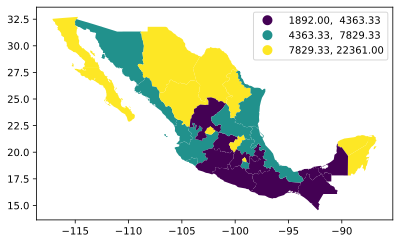

In [39]:
gdf.plot("PCGDP1940", scheme="quantiles", k=3, legend=True)

<Axes: >

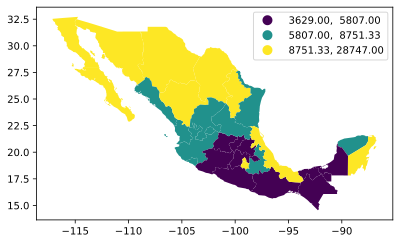

In [40]:
gdf.plot("PCGDP1950", scheme="quantiles", k=3, legend=True)

<Axes: >

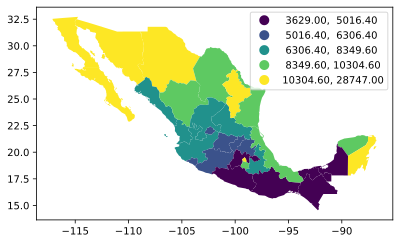

In [41]:
gdf.plot("PCGDP1950", scheme="quantiles", k=5, legend=True)

Beyond the summary statistic, an `S` object exposes the full component bookkeeping behind it: the number of components in the intersection, spatial, and attribute graphs, and the per-location labels used to build them.

In [42]:
res[-1].n_i_components

24

In [43]:
res[-1].labels

,i_labels,a_labels,g_labels
0,0,5,0
1,1,4,0
2,2,0,0
3,3,4,0
4,4,5,0
5,5,2,0
6,6,5,0
7,7,1,0
8,8,1,0
9,9,3,0


In [44]:
r0 = res[-1]

In [45]:
dir(r0)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'column',
 'labels',
 'n',
 'n_a_components',
 'n_g_components',
 'n_i_components',
 'p_value',
 'permutations',
 'statistic_']

In [46]:
r0.permutations

999

In [47]:
r0.statistic_

0.31999999999999995

In [48]:
r0.p_value

np.float64(0.445)

## Comparing polarization across decades and classification schemes

Putting it together, we compute the index, its Monte Carlo p-value, and the number of intersection components for every combination of `k in [2, 3, 5, 7]` and decade, and collect the results into a single dataframe for comparison - in the same spirit as the paper's comparison of the spatial polarization trajectory against Theil's T over time.

In [49]:
rng = numpy.random.default_rng(42)

res = []
for k in [2, 3, 5, 7]:
    for year in [1940, 1950, 1960, 1970, 1980, 1990, 2000]:
        v = f"PCGDP{year}"
        r = S(gdf, sg, v, k=k)
        res.append([year, k, r.statistic_, r.p_value, r.n_i_components])

  0%|          | 0/999 [00:00<?, ?it/s]

 39%|███▊      | 387/999 [00:00<00:00, 3863.54it/s]

 77%|███████▋  | 774/999 [00:00<00:00, 3784.69it/s]

100%|██████████| 999/999 [00:00<00:00, 3670.72it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

...

100%|██████████| 999/999 [00:00<00:00, 3457.93it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

 37%|███▋      | 374/999 [00:00<00:00, 3732.16it/s]

 75%|███████▍  | 748/999 [00:00<00:00, 3693.41it/s]

100%|██████████| 999/999 [00:00<00:00, 3725.95it/s]

In [50]:
import pandas as pd

In [51]:
res_df = pd.DataFrame(data=np.array(res), columns=["year", "k", "s", "p", "n_i"])

In [52]:
res_df.head()

,year,k,s,p,n_i
0,1940.0,2.0,0.866667,0.089,6.0
1,1950.0,2.0,0.866667,0.105,6.0
2,1960.0,2.0,0.866667,0.113,6.0
3,1970.0,2.0,0.900000,0.026,5.0
4,1980.0,2.0,0.833333,0.293,7.0


Filtering to the statistically significant results (`p <= 0.05` under the permutation null) highlights which decade/classification combinations show spatial polarization stronger than would be expected if incomes were randomly scattered across the map rather than concentrated by geography.

In [53]:
res_df[res_df.p <= 0.05]

,year,k,s,p,n_i
3,1970.0,2.0,0.900000,0.026,5.0
8,1950.0,3.0,0.827586,0.003,8.0
14,1940.0,5.0,0.666667,0.001,14.0
15,1950.0,5.0,0.703704,0.001,13.0


In [54]:
res_df[res_df.year == 2000]

,year,k,s,p,n_i
6,2000.0,2.0,0.866667,0.115,6.0
13,2000.0,3.0,0.724138,0.072,11.0
20,2000.0,5.0,0.444444,0.328,20.0
27,2000.0,7.0,0.320000,0.447,24.0


## Summary

Across both the synthetic lattice and the Mexican states application, `S` quantifies something inequality measures like the Gini index or Theil's T cannot: whether similar values are *organized in space*. As Rey (2026) shows for Mexico, national income inequality (Theil's T) and spatial polarization can move independently - inequality between states can fall even while the geographic clustering of rich and poor states persists or intensifies, consistent with a persistent poverty trap in the south alongside a more spatially fragmented set of high-income states elsewhere in the country.